<a href="https://colab.research.google.com/github/shash06sp/AI-Enabled-Structural-Health-Monitoring-using-Piezoelectric-Sensor/blob/main/Piezo_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- [Step 1] Loading Sensor Fusion Data ---
Loaded 33 Multi-Sensor Cracked Samples.
Generating Multi-Sensor Healthy Baseline...
Generated 35 Augmented Healthy Samples.
--- [Step 2] Extracting 24-Dimensional Features ---

--- [Obj: 1] Training Classifier ---
 SVM Accuracy: 92.86%


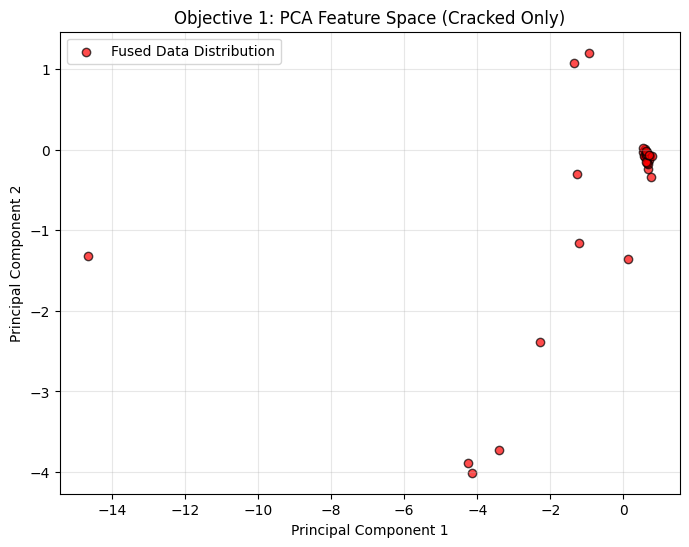


--- [Obj: 2] GPR Training ---


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GPR MAE: 25.09 mm


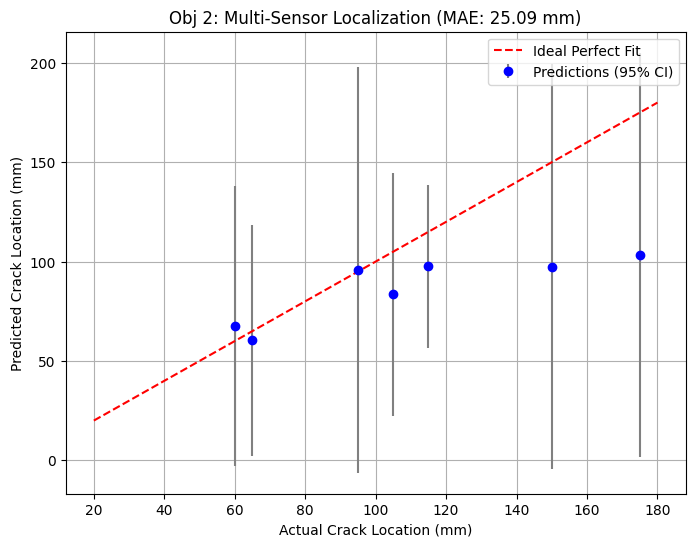


--- [Obj: 3] Dynamic Health Monitoring Simulation ---


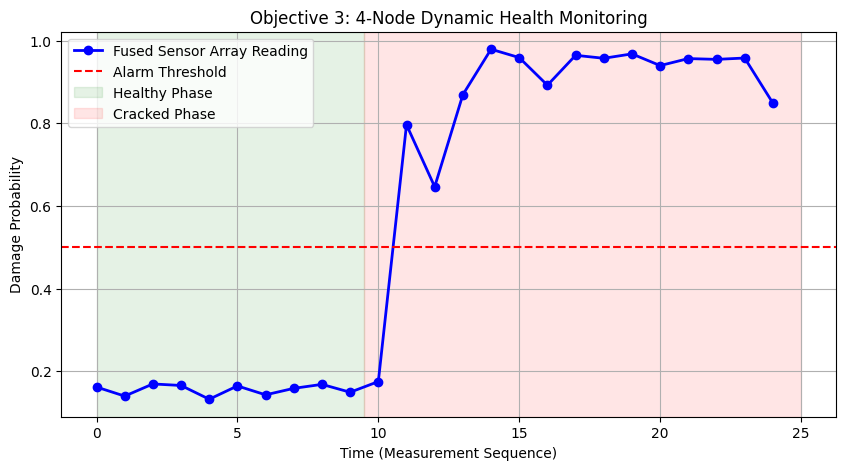

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.signal import hilbert
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, WhiteKernel, Matern
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, accuracy_score

print("--- [Step 1] Loading Sensor Fusion Data ---")
filename = 'gpr_training_dataset_final.csv'

with open(filename, 'r') as f:
    lines = f.readlines()
header_row = 0
for i, line in enumerate(lines):
    if 'Time (s)' in line:
        header_row = i
        break

df_wide = pd.read_csv(filename, skiprows=header_row)
time_values = df_wide['% Time (s)'].values

cracked_data = []
points = [14, 16, 22, 24]

crack_locations = set()
for col in df_wide.columns:
    match = re.search(r'crack_x=([\d\.]+)', col)
    if match:
        crack_locations.add(float(match.group(1)))
crack_locations = sorted(list(crack_locations))

for x in crack_locations:
    sample_dict = {'crack_x': x, 'label': 1}
    for pt in points:
        col_name = [c for c in df_wide.columns if f"crack_x={int(x) if x.is_integer() else x}," in c and f"Point: {pt}" in c]
        if col_name:
            sample_dict[f'signal_pt{pt}'] = df_wide[col_name[0]].values
    cracked_data.append(sample_dict)

print(f"Loaded {len(cracked_data)} Multi-Sensor Cracked Samples.")

healthy_data = []
template_sample = cracked_data[0]

print("Generating Multi-Sensor Healthy Baseline...")
for i in range(35):
    h_sample = {'crack_x': 0, 'label': 0}
    for pt in points:
        template_sig = template_sample[f'signal_pt{pt}']
        healed_sig = np.roll(template_sig, -5)
        amp_scale = np.random.uniform(0.90, 1.10)
        noise = np.random.normal(0, 2e-6, len(healed_sig))
        h_sample[f'signal_pt{pt}'] = (healed_sig * amp_scale) + noise
    healthy_data.append(h_sample)

print(f"Generated {len(healthy_data)} Augmented Healthy Samples.")
all_samples = healthy_data + cracked_data
df_all = pd.DataFrame(all_samples)

print("--- [Step 2] Extracting 24-Dimensional Features ---")
def get_fused_features(row):
    features = {}
    for pt in points:
        sig = row[f'signal_pt{pt}']

        rms = np.sqrt(np.mean(sig**2))
        kurtosis = pd.Series(sig).kurtosis()
        peak = np.max(np.abs(sig))
        p2p = np.ptp(sig)

        # Hilbert Transform T
        analytic_signal = hilbert(sig)
        amplitude_envelope = np.abs(analytic_signal)
        env_rms = np.sqrt(np.mean(amplitude_envelope**2))
        threshold = env_rms * 2.5

        arrival = np.where(amplitude_envelope > threshold)[0]
        tof = time_values[arrival[0]] if len(arrival) > 0 else 0

        fft_vals = np.fft.rfft(sig)
        fft_freq = np.fft.rfftfreq(len(sig), d=(time_values[1]-time_values[0]))
        peak_freq = fft_freq[np.argmax(np.abs(fft_vals))]

        features[f'Pt{pt}_Peak'] = peak
        features[f'Pt{pt}_P2P'] = p2p
        features[f'Pt{pt}_RMS'] = rms
        features[f'Pt{pt}_Kurtosis'] = kurtosis
        features[f'Pt{pt}_Peak_Freq'] = peak_freq
        features[f'Pt{pt}_ToF'] = tof

    return pd.Series(features)

X = df_all.apply(get_fused_features, axis=1)
y_label = df_all['label']
y_loc = df_all['crack_x']

print("\n--- [Obj: 1] Training Classifier ---")
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(X, y_label, test_size=0.2, random_state=42)

scaler_cls = StandardScaler()
X_cls_train_s = scaler_cls.fit_transform(X_cls_train)
X_cls_test_s = scaler_cls.transform(X_cls_test)

param_grid = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf']}
grid = GridSearchCV(SVC(probability=True, random_state=42), param_grid, cv=3)
grid.fit(X_cls_train_s, y_cls_train)

best_svm = grid.best_estimator_
acc = accuracy_score(y_cls_test, best_svm.predict(X_cls_test_s))
print(f" SVM Accuracy: {acc*100:.2f}%")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler_cls.transform(X))

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y_label==1, 0], X_pca[y_label==1, 1], c='red', label='Fused Data Distribution', edgecolors='k', alpha=0.7)
plt.title('Objective 1: PCA Feature Space (Cracked Only)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- [Obj: 2] GPR Training ---")
mask_crack = y_label == 1
X_reg = X[mask_crack]
y_reg = y_loc[mask_crack]
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
scaler_reg = StandardScaler()
X_reg_train_s = scaler_reg.fit_transform(X_reg_train)
X_reg_test_s = scaler_reg.transform(X_reg_test)

kernel = C(1.0, (1e-1, 1e2)) * Matern(length_scale=1.0, length_scale_bounds=(1e-1, 1e1), nu=1.5) \
         + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-7, 1e-2))

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50, normalize_y=True, random_state=42)
gpr.fit(X_reg_train_s, y_reg_train)
y_pred, y_std = gpr.predict(X_reg_test_s, return_std=True)
mae = mean_absolute_error(y_reg_test, y_pred)
print(f"GPR MAE: {mae:.2f} mm")

plt.figure(figsize=(8, 6))
plt.errorbar(y_reg_test, y_pred, yerr=1.96*y_std, fmt='o', c='blue', ecolor='gray', label='Predictions (95% CI)')
plt.plot([20, 180], [20, 180], 'r--', label='Ideal Perfect Fit')
plt.title(f'Obj 2: Multi-Sensor Localization (MAE: {mae:.2f} mm)')
plt.xlabel('Actual Crack Location (mm)')
plt.ylabel('Predicted Crack Location (mm)')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- [Obj: 3] Dynamic Health Monitoring Simulation ---")
monitor_timeline = healthy_data[:10] + cracked_data[:15]
di_values = []

for i, sample in enumerate(monitor_timeline):
    live_row = {}
    for pt in points:
        original_sig = sample[f'signal_pt{pt}']
        live_noise = np.random.normal(0, 1e-6, len(original_sig))
        live_row[f'signal_pt{pt}'] = original_sig + live_noise

    feats_series = get_fused_features(live_row)
    feats_df = pd.DataFrame([feats_series])
    feats_s = scaler_cls.transform(feats_df)
    prob_healthy = best_svm.predict_proba(feats_s)[0][0]
    di_values.append(1 - prob_healthy)

plt.figure(figsize=(10, 5))
plt.plot(di_values, 'b-o', linewidth=2, label='Fused Sensor Array Reading')
plt.axhline(y=0.5, color='r', linestyle='--', label='Alarm Threshold')
plt.axvspan(0, 9.5, color='green', alpha=0.1, label='Healthy Phase')
plt.axvspan(9.5, 25, color='red', alpha=0.1, label='Cracked Phase')

plt.title('Objective 3: 4-Node Dynamic Health Monitoring')
plt.xlabel('Time (Measurement Sequence)')
plt.ylabel('Damage Probability')
plt.legend()
plt.grid(True)
plt.show()